In [16]:
import os
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


def collect_metrics(root: str):
    """
    Scan root/*_vs_*_k4/eval_results.txt and compute mean ACC/AUC/F1
    for each (cell1, cell2) pair.

    Parameters
    ----------
    root : str or Path
        Directory containing subfolders like 'CellA_vs_CellB_k4'.

    Returns
    -------
    metrics : dict
        {(cell1, cell2): {'acc': float, 'auc': float, 'f1': float}, ...}
    """
    pat = re.compile(r"(.+?)_vs_(.+?)_k4$")
    metrics = {}

    root = str(root)

    for txt in glob.glob(os.path.join(root, "*_vs_*_k4", "eval_results.txt")):
        folder = os.path.basename(os.path.dirname(txt))
        m = pat.match(folder)
        if not m:
            continue

        c1, c2 = m.group(1), m.group(2)
        key = tuple(sorted((c1, c2)))

        df = pd.read_csv(
            txt,
            sep=r"\s+",
            header=None,
            names=["label", "acc", "auc", "f1"],
        )

        metrics[key] = {
            "acc": df["acc"].mean(),
            "auc": df["auc"].mean(),
            "f1": df["f1"].mean(),
        }

    return metrics


def build_matrices(metrics: dict):
    """
    Build symmetric matrices for auc/acc/f1 over all cell types.

    Returns
    -------
    cells : list[str]
        Sorted list of all cell names.
    mats : dict[str, np.ndarray]
        'auc', 'acc', 'f1' -> (n x n) matrices.
    """
    cells = sorted({c for pair in metrics for c in pair})
    n = len(cells)
    idx = {c: i for i, c in enumerate(cells)}

    mats = {k: np.full((n, n), np.nan) for k in ["auc", "acc", "f1"]}

    for (c1, c2), vals in metrics.items():
        i, j = idx[c1], idx[c2]
        for k in mats:
            mats[k][i, j] = mats[k][j, i] = vals[k]

    return cells, mats




# def plot_heatmap(mat, cells, title, ax, vmin=0.2, vmax=1.0):
#     # Use a colormap
#     cmap = plt.cm.viridis
#     im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

#     # Ticks
#     ax.set_xticks(range(len(cells)))
#     ax.set_yticks(range(len(cells)))
#     ax.set_xticklabels(cells, rotation=45, ha="right", fontsize=11)
#     ax.set_yticklabels(cells, fontsize=11)

#     ax.set_title(title)

#     # Get colormap normalization so we can convert values to colors
#     norm = plt.Normalize(vmin=vmin, vmax=vmax)

#     # Annotate only lower triangle (including diagonal)
#     for i in range(len(cells)):
#         for j in range(i + 1):
#             val = mat[i, j]
#             if not np.isnan(val):
#                 # Get RGBA color of the cell
#                 rgba = cmap(norm(val))
#                 # Compute perceived brightness (luminance)
#                 r, g, b, _ = rgba
#                 luminance = 0.299*r + 0.587*g + 0.114*b

#                 # If dark background → white text; otherwise black
#                 text_color = "white" if luminance < 0.5 else "black"

#                 ax.text(j, i, f"{val:.2f}",
#                         ha="center", va="center",
#                         fontsize=11, color=text_color)

#     # Colorbar
#     plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def plot_heatmap(mat, cells, title, ax, vmin=0.2, vmax=1.0):
    cmap = plt.cm.viridis
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(cells)))
    ax.set_yticks(range(len(cells)))
    ax.set_xticklabels(cells, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(cells, fontsize=11)
    ax.set_title(title)

    # normalization for colormap
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # annotate only lower triangle (including diagonal)
    for i in range(len(cells)):
        for j in range(i + 1):
            val = mat[i, j]
            if not np.isnan(val):
                rgba = cmap(norm(val))
                r, g, b, _ = rgba
                luminance = 0.299*r + 0.587*g + 0.114*b
                text_color = "white" if luminance < 0.5 else "black"

                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=11, color=text_color
                )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


from pathlib import Path

def make_compartment_heatmaps(root, out_prefix):
    """
    Generate three separate heatmap PDFs:
      - {out_prefix}_auc.pdf
      - {out_prefix}_acc.pdf
      - {out_prefix}_f1.pdf
    """
    root = Path(root)

    metrics = collect_metrics(str(root))
    if not metrics:
        raise RuntimeError(f"No eval_results.txt files found under {root}.")

    cells, mats = build_matrices(metrics)

    # Desired order
    desired_order = [
        "Compartment_A_25kbp",
        "Compartment_StrongA_25kbp",
        "Compartment_B_25kbp",
        "Compartment_StrongB_25kbp",
    ]

    cells_reordered = [c for c in desired_order if c in cells]
    if not cells_reordered:
        raise RuntimeError("None of the desired compartments were found in the data.")

    # map to original indices
    idx = {c: i for i, c in enumerate(cells)}
    perm = [idx[c] for c in cells_reordered]

    # reorder matrices
    for k in mats:
        mats[k] = mats[k][np.ix_(perm, perm)]

    # mask upper triangle
    n = len(cells_reordered)
    tril_mask = np.tril(np.ones((n, n), dtype=bool), k=0)
    for k in mats:
        mats[k][~tril_mask] = np.nan

    # save three separate PDFs
    for key, title in [
        ("auc", "Mean AUC"),
        ("acc", "Mean Accuracy"),
        ("f1", "Mean F1 Score"),
    ]:
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_heatmap(mats[key], cells_reordered, title, ax)
        fig.tight_layout()

        out_path = f"{out_prefix}_{key}.pdf"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] saved {out_path}")

        plt.show()
        plt.close(fig)




[INFO] saved ./Revision_code/Fig8a/metrics_heatmaps.pdf_auc.pdf


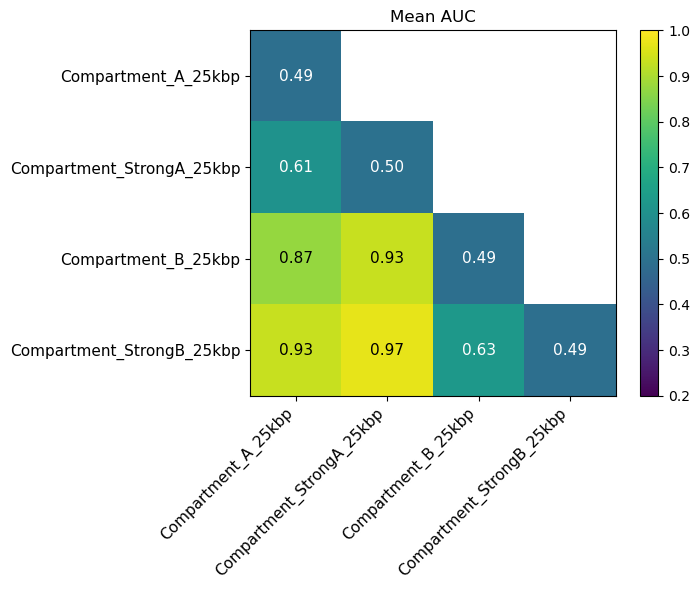

[INFO] saved ./Revision_code/Fig8a/metrics_heatmaps.pdf_acc.pdf


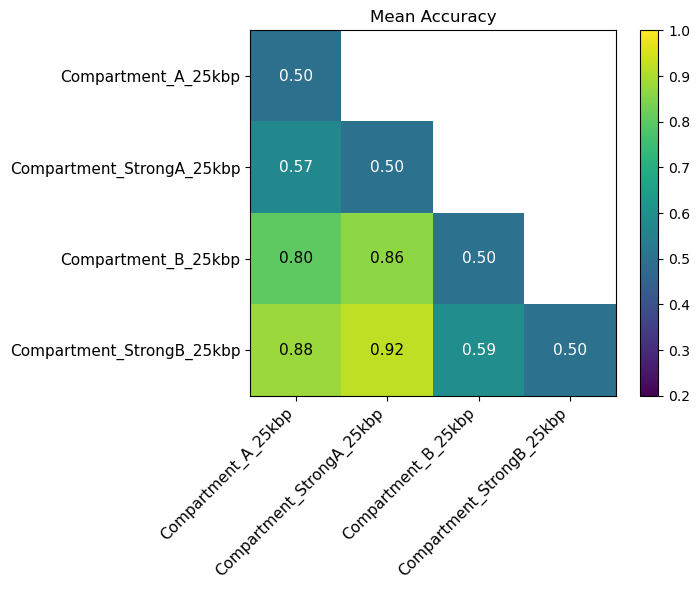

[INFO] saved ./Revision_code/Fig8a/metrics_heatmaps.pdf_f1.pdf


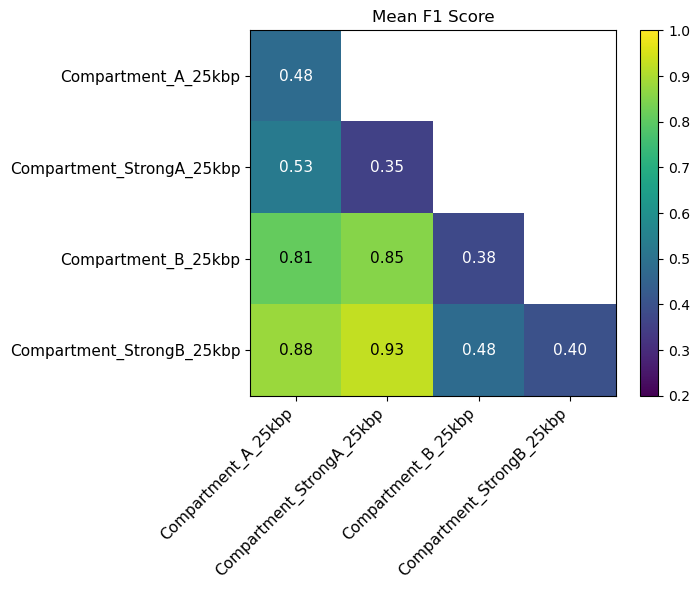

In [17]:
root_dir = "../revision_temp/finetune_results_train50000_dev5000_notomitO/ext12500_stride1_notomitO_eval"
outfile = "./Revision_code/Fig8a/metrics_heatmaps.pdf"

make_compartment_heatmaps(root_dir, outfile)



In [52]:
def make_boxplot(eval_results_path, out_pdf_path):
    """
    Replicates boxplot.py inside the notebook, with simple custom box colors.
    """
    eval_results_path = Path(eval_results_path)
    out_pdf_path = Path(out_pdf_path)

    # Load eval results
    df = pd.read_csv(
        eval_results_path,
        sep=r"\s+",
        header=None,
        names=["Label", "Accuracy", "AUC", "F1"]
    )

    # Determine plot title
    title = df["Label"].iloc[0] if df["Label"].nunique() == 1 else "Summary"

    fig, ax = plt.subplots(figsize=(6, 5))

    data = [df["Accuracy"], df["AUC"], df["F1"]]
    labels = ["Accuracy", "AUC", "F1 Score"]

    bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True
    )

    # Simple face colors
    colors = ["steelblue", "green", "orange"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    # -----------------------------
    # Line color changes (place here)
    # -----------------------------
    line_color = "black"  # ← change this

    for box in bp["boxes"]:
        box.set_edgecolor(line_color)

    for median in bp["medians"]:
        median.set_color("red")

    for whisker in bp["whiskers"]:
        whisker.set_color(line_color)

    for cap in bp["caps"]:
        cap.set_color(line_color)
    # -----------------------------

    ax.set_title(title)
    ax.set_ylim([0.5, 0.8])
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_xlabel("Metric", fontsize=15)
    ax.set_ylabel("Score", fontsize=15)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.tight_layout()


    out_pdf_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_pdf_path, dpi=300)

    plt.show()
    plt.close(fig)

    print(f"[SAVED] {out_pdf_path}")



Processing ext25000_stride1_notomitO...


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_29887/3163027161.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


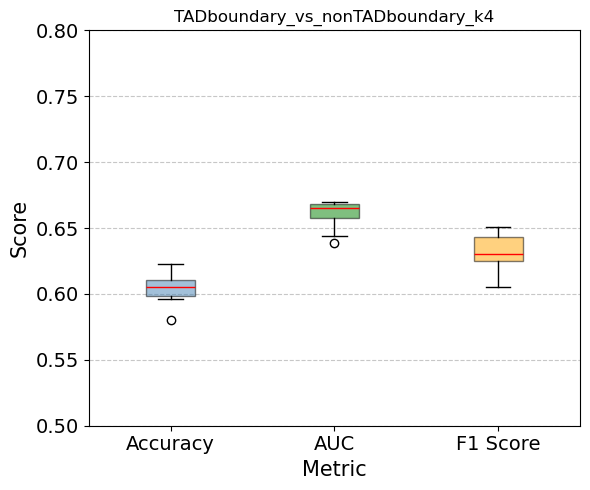

[SAVED] Revision_code/Fig8b/boxplot_TADboundary_ext25000_stride1_notomitO.pdf

Processing ext100000_stride2_notomitO...


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_29887/3163027161.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


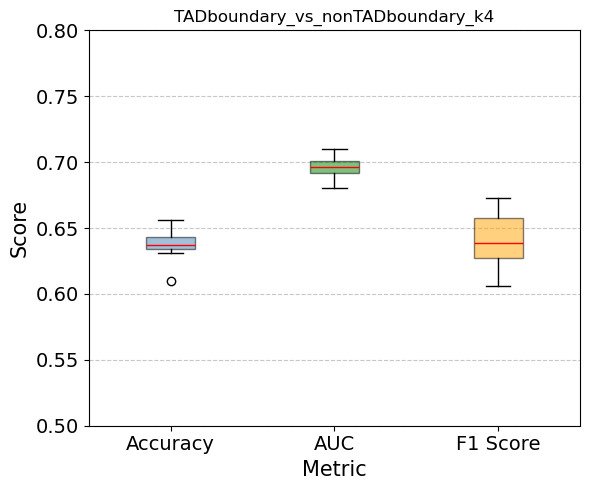

[SAVED] Revision_code/Fig8b/boxplot_TADboundary_ext100000_stride2_notomitO.pdf


In [53]:
# ==========================================
# LOOP FOR PARAMETERS — SAVE INTO Fig8b
# ==========================================

base_dir = Path("../revision_temp/finetune_results_train50000_dev5000_notomitO")

params = [
    "ext25000_stride1_notomitO",
    "ext100000_stride2_notomitO",
    # "ext50000_stride1_notomitO",  # Add if exists
]

# Output directory you want
target_dir = Path("./Revision_code/Fig8b")

for param in params:
    print(f"\nProcessing {param}...")

    eval_path = (
        base_dir / param / "TADboundary_vs_nonTADboundary_k4" / "eval_results.txt"
    )

    # Output filename under Fig8b
    out_pdf = target_dir / f"boxplot_TADboundary_{param}.pdf"

    make_boxplot(eval_path, out_pdf)